# Machine Learning

> [!NOTE]
> To recap the concepts you learned today, you will train a machine learning classifier and apply the methods to a real-world dataset. You may reuse the dataset from previous assignments or select a new one. Remember the [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/) is a great source for datasets. A pre-selection of candidates is provided below.
> 
> **Task Instructions**
> 1.	Choose a dataset (**at least one**).
> 2.	Identify features and target categories suitable for classification.
> 3.	Train and evaluate classifiers covered in the lecture (e.g., logistic regression, decision trees, k-nearest neighbors, etc.).
> 4.	Assess performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score, confusion matrix).
> 5.	Interpret the results and reflect on the strengths and limitations of your approach.

In [ ]:
# 1. Dataset selection // Copied from lab09

from ucimlrepo import fetch_ucirepo 
import pandas as pd

# Code used from the link shown below
# Link adult dataset - https://archive.ics.uci.edu/dataset/2/adult

# fetch dataset 
adult = fetch_ucirepo(id=2) 

# data (as pandas dataframes) 
x = adult.data.features 
y = adult.data.targets 

# 2D -> 1D array (added after a DataconversionWarning)
y = y.values.ravel()

print("Done Fetching")

# metadata 
print(adult.metadata) 

# variable information 
print(adult.variables) 

#### 2. Task
Target column => income
- <=50K
- \>50K

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


# Identify categorical and numerical columns (conversion)
categorical_cols = x.select_dtypes(include=["object"]).columns
numerical_cols = x.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)
print("Preprocessing done")

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("Data Split done")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# Logistic Regression Model

# Pipeline that preproccesses & does regression
regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean=False)), # Added after a Warning and further research (ConvergenceWarning)
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train the model 
regression_model.fit(X_train, y_train)
print("regression training done")

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Decision Tree Model

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

decision_tree_model.fit(X_train, y_train)
print("decision training done")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# KNN Model

knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("scaler", StandardScaler(with_mean=False)), # Added after further reasearch (KNN sensitive to feature scales)
    ("classifier", KNeighborsClassifier())
])

knn_model.fit(X_train, y_train)
print("knn training done")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# Evaluate Models

def evaluate_model(model, model_name):
    # Predeict labels
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    # Performance metrics
    print(f"\nEvaluation: {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    return accuracy
    



Evaluation: Logistic Regression
Accuracy: 0.5945337291432081
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.61      0.93      0.73      4945
      <=50K.       0.90      0.10      0.17      2487
        >50K       0.50      0.62      0.55      1568
       >50K.       0.50      0.02      0.05       769

    accuracy                           0.59      9769
   macro avg       0.63      0.42      0.38      9769
weighted avg       0.66      0.59      0.51      9769

Confusion Matrix:
 [[4582    8  354    1]
 [2065  240  172   10]
 [ 592    1  967    8]
 [ 289   18  443   19]]


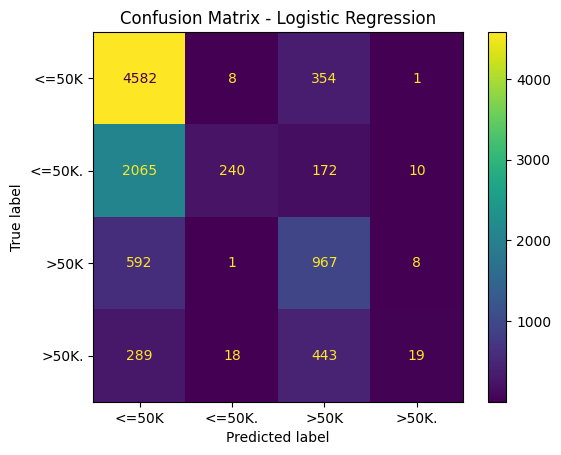


Evaluation: Decision Tree
Accuracy: 0.48142082096427474
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.61      0.60      0.61      4945
      <=50K.       0.34      0.35      0.35      2487
        >50K       0.43      0.43      0.43      1568
       >50K.       0.23      0.24      0.23       769

    accuracy                           0.48      9769
   macro avg       0.40      0.40      0.40      9769
weighted avg       0.48      0.48      0.48      9769

Confusion Matrix:
 [[2979 1376  404  186]
 [1319  868  186  114]
 [ 395  174  672  327]
 [ 172  112  301  184]]


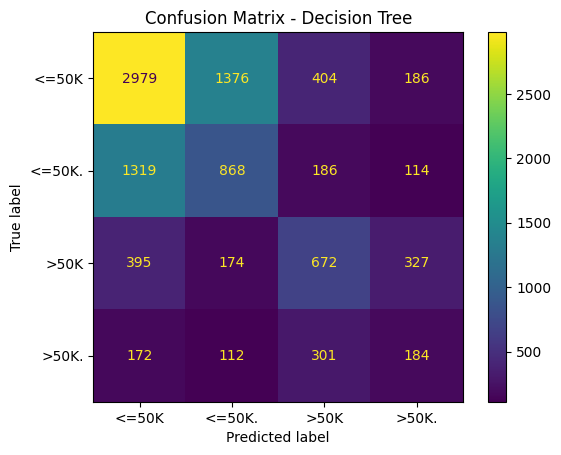


Evaluation: K-Nearest Neighbors
Accuracy: 0.5229808578155389
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.59      0.75      0.66      4945
      <=50K.       0.37      0.25      0.30      2487
        >50K       0.47      0.43      0.45      1568
       >50K.       0.26      0.10      0.14       769

    accuracy                           0.52      9769
   macro avg       0.42      0.38      0.39      9769
weighted avg       0.49      0.52      0.49      9769

Confusion Matrix:
 [[3732  829  322   62]
 [1676  623  147   41]
 [ 642  134  677  115]
 [ 301   89  302   77]]


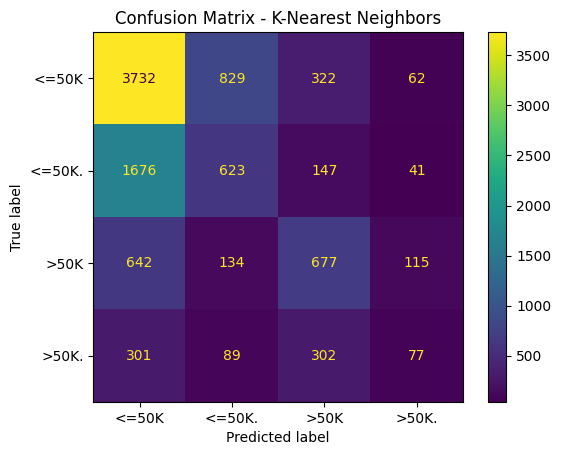

,Model,Accuracy
0,Logistic Regression,0.594534
2,K-Nearest Neighbors,0.522981
1,Decision Tree,0.481421


In [42]:
# Evaluate all models and compare Accuracy
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "K-Nearest Neighbors"],
    "Accuracy": [
        evaluate_model(regression_model, "Logistic Regression"),
        evaluate_model(decision_tree_model, "Decision Tree"),
        evaluate_model(knn_model, "K-Nearest Neighbors")
    ]
}).sort_values("Accuracy", ascending=False)

results

#### 5. Task Evaluation

I used 3 different machine learning models in this notebook: Logistic Regression, Descision Tree and knn  
Logistic Regression performed the best with an accuracy of about **59%**. It worked well for predicting the `<=50K` income group but had trouble correctly predicting people who earn more than 50K. This is likely because the data is unbalanced and because Logistic Regression cannot model very complex patterns.  

k-Nearest Neighbors achieved around **52%** accuracy. It did okay for the majority class but performed poorly on smaller classes. This model is very sensitive to how the data is scaled and to the choice of the number of neighbors, which may explain its lower performance.  

The Decision Tree had the lowest accuracy at around **48%**. Although decision trees can handle non-linear data, this model likely overfits the training data and does not generalize well without tuning its parameters.

Overall, Logistic Regression gave the most reliable results. The main limitations of this work are class imbalance, high dimensionality from one-hot encoding, and the lack of hyperparameter tuning. These issues could be improved in future work.  

``(DISCLAIMER: Corrected with ChatGPT)``